# PMOF action timelines per person

This notebook plots the temporal action sequence of every annotated person in every PMOF recording. Each bar represents one `(recording, track ID)` pair; stacked segments run from the first observed frame at the bottom to the last observed frame at the top.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Paths come from path_config.yaml; edit that file's current_workstation to switch machines.
from path_config import PMOF_CODE_DIR, DATA_BASE_DIR

# Set to None to analyze all recordings, or provide IDs such as ["rec1", "rec7", "rec12"].
SELECTED_RECORD_IDS = [f"rec{i}" for i in range(1,31)]

# When True, show seated_ground annotations as lying in the timeline and legend.
MAP_SEATED_GROUND_TO_LYING = False

if not PMOF_CODE_DIR.is_dir():
    raise FileNotFoundError(f"PMOF code directory not found: {PMOF_CODE_DIR}")
if not (DATA_BASE_DIR / "images").is_dir() or not (DATA_BASE_DIR / "annotations").is_dir():
    raise FileNotFoundError(
        "DATA_BASE_DIR must contain both 'images' and 'annotations' directories. "
        f"Current value: {DATA_BASE_DIR}"
    )

sys.path.insert(0, str(PMOF_CODE_DIR))

from src.data import list_record_ids, read_annotation, recid_to_annpath, recordid_to_imageids
from src.visualization import VIZ_PARAMS

ACTION_COLORS = VIZ_PARAMS["gt_bbox_colors"]
ACTION_ORDER = ["seated", "seated_ground", "standing", "lying"]

In [7]:
def frame_number(image_id: str) -> int:
    """Extract the numeric frame index from an ID such as ``rec12_000345``."""
    return int(image_id.rsplit("_", maxsplit=1)[1])


def selected_record_ids(data_base_dir: Path, requested_ids: list[str] | None) -> list[str]:
    """Return all PMOF records or a validated user-selected subset."""
    available_ids = list_record_ids(data_base_dir)
    if requested_ids is None:
        return available_ids

    unknown_ids = sorted(set(requested_ids) - set(available_ids))
    if unknown_ids:
        raise ValueError(
            "Selected record IDs are not present in this dataset: "
            + ", ".join(unknown_ids)
        )
    return [record_id for record_id in available_ids if record_id in requested_ids]


def normalized_action(action: str) -> str:
    """Apply the optional display mapping for action annotations."""
    if MAP_SEATED_GROUND_TO_LYING and action == "seated_ground":
        return "lying"
    return action


def load_person_actions(data_base_dir: Path, record_ids: list[str]) -> pd.DataFrame:
    """Read every annotated person action with PMOF's dataset and annotation helpers."""
    action_rows = []

    for record_id in record_ids:
        annotation_path = recid_to_annpath(record_id, data_base_dir)
        for image_id in recordid_to_imageids(record_id, data_base_dir):
            for annotation in read_annotation(annotation_path, image_id):
                if annotation.category_name != "person" or annotation.action is None:
                    continue
                action_rows.append(
                    {
                        "record_id": record_id,
                        "frame": frame_number(image_id),
                        "track_id": annotation.track_id,
                        "action": normalized_action(annotation.action),
                        "occluded": bool(annotation.occluded),
                    }
                )

    frame_actions = pd.DataFrame(
        action_rows, columns=["record_id", "frame", "track_id", "action", "occluded"]
    )
    if frame_actions.empty:
        raise ValueError("No person annotations with an action attribute were found.")

    unsupported_actions = sorted(set(frame_actions["action"]) - set(ACTION_ORDER))
    if unsupported_actions:
        raise ValueError(
            "Expected only PMOF actions "
            f"{ACTION_ORDER}; found: {', '.join(unsupported_actions)}"
        )
    if frame_actions.duplicated(["record_id", "frame", "track_id"]).any():
        raise ValueError("A person has multiple action annotations in the same frame.")

    return frame_actions.sort_values(["record_id", "track_id", "frame"]).reset_index(drop=True)


record_order = selected_record_ids(DATA_BASE_DIR, SELECTED_RECORD_IDS)
frame_actions = load_person_actions(DATA_BASE_DIR, record_order)
frame_actions.head()

,record_id,frame,track_id,action,occluded
0,rec1,2509,0,seated,False
1,rec1,2511,0,seated,False
2,rec1,2512,0,seated,False
3,rec1,2513,0,seated,False
4,rec1,2514,0,seated,False


In [8]:
def consecutive_action_runs(person_frames: pd.DataFrame) -> list[dict]:
    """Collapse consecutive equal (action, occluded) pairs while retaining chronological order."""
    runs = []
    current_key = None
    run_start = None
    run_end = None
    frame_count = 0

    for row in person_frames.sort_values("frame").itertuples(index=False):
        key = (row.action, row.occluded)
        if key != current_key:
            if current_key is not None:
                runs.append(
                    {
                        "action": current_key[0],
                        "occluded": current_key[1],
                        "start_frame": run_start,
                        "end_frame": run_end,
                        "frame_count": frame_count,
                    }
                )
            current_key = key
            run_start = row.frame
            frame_count = 0
        run_end = row.frame
        frame_count += 1

    if current_key is not None:
        runs.append(
            {
                "action": current_key[0],
                "occluded": current_key[1],
                "start_frame": run_start,
                "end_frame": run_end,
                "frame_count": frame_count,
            }
        )
    return runs


run_rows = []
for (record_id, track_id), person_frames in frame_actions.groupby(["record_id", "track_id"], sort=True):
    for run in consecutive_action_runs(person_frames):
        run_rows.append({"record_id": record_id, "track_id": track_id, **run})

action_runs = pd.DataFrame(run_rows)
action_runs.head(10)

,record_id,track_id,action,occluded,start_frame,end_frame,frame_count
0,rec1,0,seated,False,2509,3353,810
1,rec1,1,seated,False,2509,3353,810
2,rec1,2,seated,False,2509,3353,810
3,rec10,0,seated,False,900,2077,1027
4,rec10,1,seated,False,900,2077,1027
5,rec11,0,seated,False,804,1978,1061
6,rec12,0,seated,False,1711,2004,294
7,rec12,1,seated,False,1711,2004,294
8,rec13,0,seated,False,1670,2053,370
9,rec13,1,seated,False,1670,2053,370


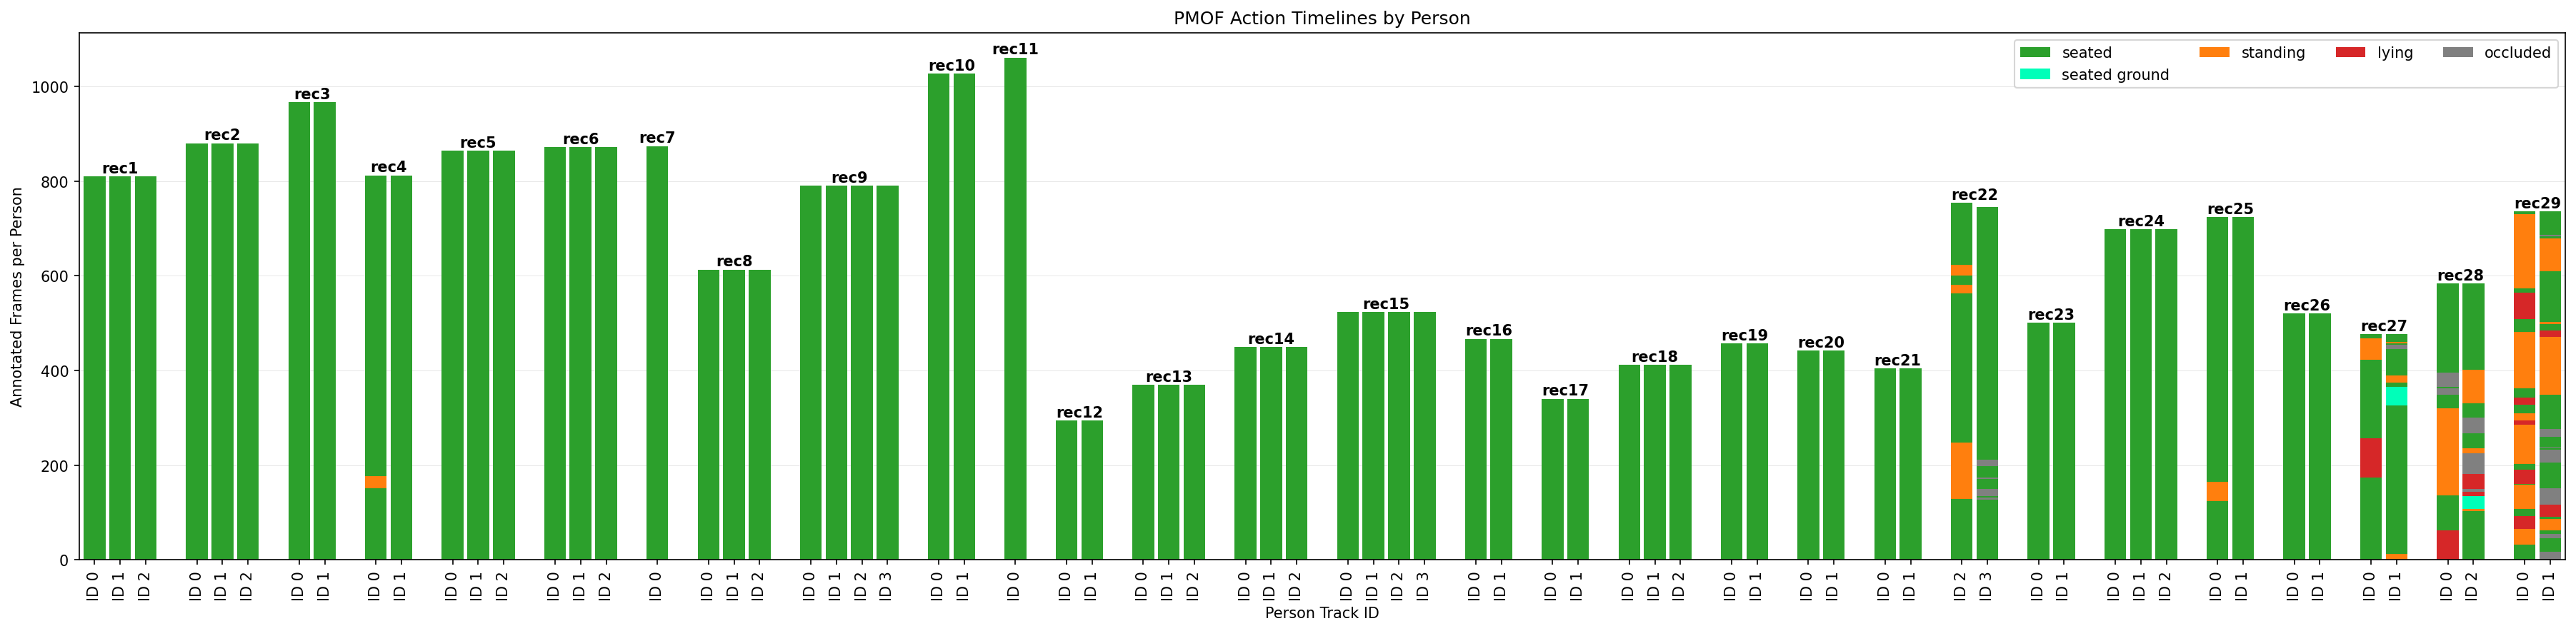

In [12]:
record_tracks = {
    record_id: sorted(
        frame_actions.loc[frame_actions["record_id"] == record_id, "track_id"].unique()
    )
    for record_id in record_order
}

record_gap = 1.5
OCCLUDED_COLOR = "grey"
track_order = []
track_positions = []
record_centers = {}
record_top_heights = {}
next_position = 0.0

for record_id in record_order:
    track_ids = record_tracks[record_id]
    positions = list(range(int(next_position), int(next_position) + len(track_ids)))
    track_order.extend((record_id, track_id) for track_id in track_ids)
    track_positions.extend(positions)
    record_centers[record_id] = (positions[0] + positions[-1]) / 2
    next_position = positions[-1] + 1 + record_gap

fig, ax = plt.subplots(figsize=(max(12, 0.35 * len(track_order)), 6), dpi=150)

for position, (record_id, track_id) in zip(track_positions, track_order):
    person_runs = action_runs.loc[
        (action_runs["record_id"] == record_id)
        & (action_runs["track_id"] == track_id)
    ].sort_values("start_frame")
    bottom = 0

    for run in person_runs.itertuples(index=False):
        bar_color = OCCLUDED_COLOR if run.occluded else ACTION_COLORS[run.action]
        ax.bar(
            position,
            run.frame_count,
            bottom=bottom,
            width=0.85,
            color=bar_color,
            edgecolor="none",
            antialiased=False,
        )
        bottom += run.frame_count

    record_top_heights[record_id] = max(record_top_heights.get(record_id, 0), bottom)

observed_actions = set(action_runs["action"])
legend_handles = [
    Patch(facecolor=ACTION_COLORS[action], label=action.replace("_", " "))
    for action in ACTION_ORDER
    if action in observed_actions
]
if action_runs["occluded"].any():
    legend_handles.append(Patch(facecolor=OCCLUDED_COLOR, label="occluded"))
ax.legend(handles=legend_handles, ncols=min(4, len(legend_handles)))
ax.set_xticks(track_positions)
ax.set_xticklabels([f"ID {track_id}" for _, track_id in track_order], rotation=90)
ax.set_xlabel("Person Track ID")
ax.set_ylabel("Annotated Frames per Person")
ax.set_title("PMOF Action Timelines by Person")
ax.set_xlim(track_positions[0] - 0.6, track_positions[-1] + 0.6)
ax.grid(axis="y", linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for record_id, center in record_centers.items():
    ax.annotate(
        record_id,
        xy=(center, record_top_heights[record_id]-20),
        xycoords="data",
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
        clip_on=False,
    )

fig.tight_layout()
plt.show()